In [124]:
from evoscape.jax.flax_models.landscape_flax import LandscapeFlax
from evoscape.jax.flax_models.autoencoder_flax import AutoEncoder

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from flax import nnx

from evoscape.landscapes import Landscape
from evoscape.modules import Node, UnstableNode, Center, NegCenter
from evoscape.morphogen_regimes import mr_const, mr_sigmoid
from evoscape.landscape_visuals import plot_traj, visualize_landscape, visualize_landscape_t
from evoscape.jax.dynamics import state_probs
from evoscape.jax.utils import get_drosophile_data, get_facs_data
from evoscape.jax.config import DATA_DIR
from evoscape.jax.losses import mmd_traj, sinkhorn_traj

from sklearn.mixture import GaussianMixture

plt.style.use("default")

As you will see, the notebooks for the drosophila and the synthetic data are really similar : I'll only comment on the parts that are different, the missing explanations for the code are probably in synthetic_data_clean.ipynb

## Creating the landscape and the autoencoder

Landscape with modules:
Node: x=3.0; y=0.0; a=[0.2]; s=[1.]; tau=1.0,
Node: x=2.427051; y=1.7633557; a=[0.2]; s=[1.]; tau=1.0,
Node: x=0.92705095; y=2.8531697; a=[0.2]; s=[1.]; tau=1.0,
Node: x=-0.92705107; y=2.8531694; a=[0.2]; s=[1.]; tau=1.0,
Node: x=-2.427051; y=1.7633555; a=[0.2]; s=[1.]; tau=1.0,
Node: x=-3.0; y=-2.6226832e-07; a=[0.2]; s=[1.]; tau=1.0,
Node: x=-2.4270508; y=-1.7633561; a=[0.2]; s=[1.]; tau=1.0,
Node: x=-0.9270513; y=-2.8531694; a=[0.2]; s=[1.]; tau=1.0,
Node: x=0.92705137; y=-2.8531694; a=[0.2]; s=[1.]; tau=1.0,
Node: x=2.4270508; y=-1.763356; a=[0.2]; s=[1.]; tau=1.0


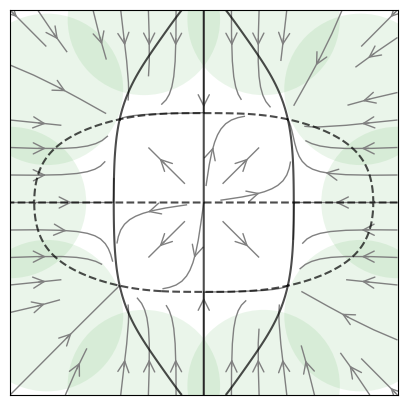

In [125]:
n_modules = 10

xx = [jnp.cos(2*jnp.pi*k/n_modules)*3 for k in range(n_modules)] 
yy = [jnp.sin(2*jnp.pi*k/n_modules)*3 for k in range(n_modules)]

modules = [Node(x=x, y=y, a=np.array([0.2]), s=np.array([1.0]), tau=1.) for x,y in zip(xx, yy)]

landscape = Landscape(
    module_list=modules,
    A0=0.05,
    init_cond=(0.0, 0.0),
    regime=mr_const,
    n_regimes=1,
    # morphogen_times=(50.,),
)

print(landscape)

L = 3.
npoints = 201
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q, q, indexing='xy')

## fig = visualize_landscape_t(landscape, xx, yy, 2., color_scheme='fp_types', traj_times=(0., 20., 201), traj_init_cond=(2.,2.), traj_start=100)
fig = visualize_landscape(landscape, xx, yy, regime=0, color_scheme='fp_types')


Here, and really often, choosing a good time for the simulation is critical.
Because we expect a spread of the cells, they shouldn't have the time to end up in a fixed point (we want the spread to be sort of injective... This will really help the decoder to do his job).

So here, the time should be reasonably small, and this is obtained through tests.
Or, equivalently, you should start with modules with a small a and sigma.
This last observation is true only because in this example we don't use noise. adding noise would add a real supplementary difficulty.

In general, I think time and noise are two very important parameters, that are linked together, and can really improve the training (or make it worse).

In [126]:

# Initializing the landscape 
rngs = nnx.Rngs(0)
landscape_flax = LandscapeFlax(landscape, rngs)

init_noise = 0.
t0 = 0.
tf = 20.
nt = 17
ndt = 50
noise = 0.

landscape_flax.set_simulation(init_noise=init_noise, t0=t0, tf=tf, nt=nt, ndt=ndt, noise=noise)
landscape_flax.set_regime_params(signal_param=None)
landscape_flax.set_state_probs(state_probs)

# Initialiazing the decoder
dims_encoder = [4, 8, 4, 2]
dims_decoder = [2, 8, 8, 4]

autoencoder = AutoEncoder(landscape_flax, dims_decoder=dims_decoder, dims_encoder=dims_encoder, rngs=rngs)

## Loading the data

get_drosophile_data is incredibly long, there is probably a problem with it.

In [127]:
filepath = DATA_DIR / "data_drosophiles" / "drosophiles_cleaned.csv"

target_traj_init = get_drosophile_data(filepath) 

In [128]:
target_traj = target_traj_init[:,0:770,:170:10]

print(target_traj.shape)

(4, 770, 17)


In [129]:
q_init = target_traj[:, :,0]
print(q_init.shape)

simulated_traj = autoencoder(q_init)
print(simulated_traj.shape)

loss = mmd_traj(simulated_traj, target_traj)
print(loss)

(4, 770)
(4, 770, 17)
6.158353


(4, 770)
(2, 770)


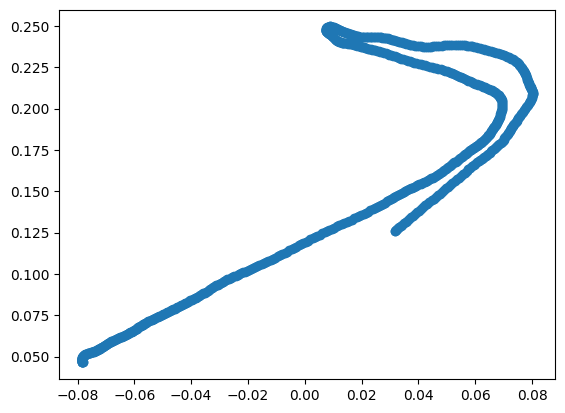

In [130]:
print(q_init.shape)
q_init_latent = nnx.vmap(lambda x : autoencoder.encoder(x), in_axes=1, out_axes=1)(q_init) # (2, n)

print(q_init_latent.shape)
plt.scatter(q_init_latent[0,:], q_init_latent[1,:])

## Training the model

Époque 0 | Loss: 0.1489
Époque 10 | Loss: 0.0271
Époque 20 | Loss: 0.0190
Époque 30 | Loss: 0.0151
Époque 40 | Loss: 0.0119
Époque 50 | Loss: 0.0085
Époque 60 | Loss: 0.0077
Époque 70 | Loss: 0.0072
Époque 80 | Loss: 0.0068
Époque 90 | Loss: 0.0066
Époque 100 | Loss: 0.0064
Époque 110 | Loss: 0.0063
Époque 120 | Loss: 0.0062
Époque 130 | Loss: 0.0060
Époque 140 | Loss: 0.0059
Époque 150 | Loss: 0.0058
Époque 160 | Loss: 0.0056
Époque 170 | Loss: 0.0055
Époque 180 | Loss: 0.0053
Époque 190 | Loss: 0.0051
Époque 200 | Loss: 0.0049
Époque 210 | Loss: 0.0046
Époque 220 | Loss: 0.0043
Époque 230 | Loss: 0.0040
Époque 240 | Loss: 0.0038
Époque 250 | Loss: 0.0035
Époque 260 | Loss: 0.0033
Époque 270 | Loss: 0.0032
Époque 280 | Loss: 0.0031
Époque 290 | Loss: 0.0039
Époque 300 | Loss: 0.0033
Époque 310 | Loss: 0.0031
Époque 320 | Loss: 0.0031
Époque 330 | Loss: 0.0030
Époque 340 | Loss: 0.0030
Époque 350 | Loss: 0.0030
Époque 360 | Loss: 0.0029
Époque 370 | Loss: 0.0029
Époque 380 | Loss: 0.00

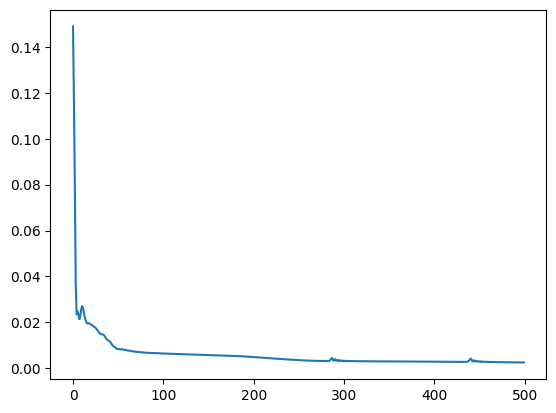

In [ ]:
# Defining the optimizer 
tx = optax.adamw(
    learning_rate = 2e-2,
    weight_decay = 2e-3,
)

optimizer = nnx.Optimizer(autoencoder, tx, wrt=nnx.Param)

# Defining the loss function, and the train_step 

def loss_fn(autoencoder, target_traj):
    # Forward pass
    q_init = target_traj[:,:,0]
    simulated_traj = autoencoder(q_init)

    # Loss on cloud points
    # this loss is useful when we don't have the trajectories. But for the drosophila we have it.
    # loss_dynamics = mmd_traj(simulated_traj, target_traj)
    loss_dynamics = jnp.mean((simulated_traj - target_traj)**2)

    # Here the loss encoding is only on the initial condition, and in reality it is performed in the loss dynamics
    # because the first term of (simulated_traj - target_traj)**2 is (q_init - decoder(encoder(q_init)))

    return loss_dynamics 


@nnx.jit
def train_step(autoencoder, optimizer: nnx.Optimizer, target_traj):
    # nnx.value_and_grad computes the gradient with respect to the nnx.Params
    loss, grads = nnx.value_and_grad(loss_fn)(autoencoder, target_traj)
    
    optimizer.update(autoencoder, grads)
    
    return loss

# Training loop 
n_epochs = 500
loss_vals = []

for epoch in range(n_epochs):
    # autoencoder.landscape_flax.sim_params["noise"] = 0.1 * (jnp.exp(-jnp.abs(epoch-20)/10))
    loss_val = train_step(autoencoder, optimizer, target_traj)
    
    if epoch%10 == 0:
        print(f"Époque {epoch} | Loss: {loss_val:.4f}")

    loss_vals.append(loss_val)

plt.plot(loss_vals)

Landscape with modules:
Node: x=2.939370632171631; y=-0.0415663868188858; a=[0.21238759]; s=[0.9802072]; tau=1.0,
Node: x=2.4504811763763428; y=1.795332908630371; a=[0.1177852]; s=[0.91351825]; tau=1.0,
Node: x=0.9374933838844299; y=2.8391776084899902; a=[0.15882279]; s=[0.9441297]; tau=1.0,
Node: x=-0.911618709564209; y=2.8081796169281006; a=[0.19564277]; s=[0.9668108]; tau=1.0,
Node: x=-2.4183731079101562; y=1.7681210041046143; a=[0.16673812]; s=[0.9405974]; tau=1.0,
Node: x=-2.963911533355713; y=-0.15303543210029602; a=[0.3106698]; s=[0.9139729]; tau=1.0,
Node: x=-2.337034225463867; y=-1.6642807722091675; a=[0.29115182]; s=[1.0180235]; tau=1.0,
Node: x=-0.9542267322540283; y=-2.8278021812438965; a=[0.17624834]; s=[0.95508665]; tau=1.0,
Node: x=0.9572077393531799; y=-2.8412864208221436; a=[0.16064475]; s=[0.9435414]; tau=1.0,
Node: x=2.3874518871307373; y=-1.7155317068099976; a=[0.20527479]; s=[0.98223656]; tau=1.0


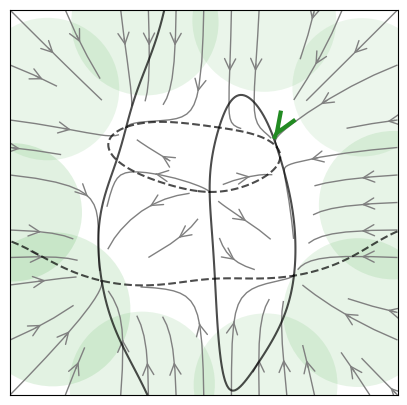

In [132]:
landscape = autoencoder.landscape_flax.get_landscape()

print(landscape)

L = 3.
npoints = 201
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q, q, indexing='xy')

fig = visualize_landscape_t(landscape, xx, yy, 20., color_scheme='fp_types', traj_times=(0., 20., 201), traj_init_cond=(2.,2.), traj_start=100)

## Analyzing the model

(4, 770)
(2, 770)


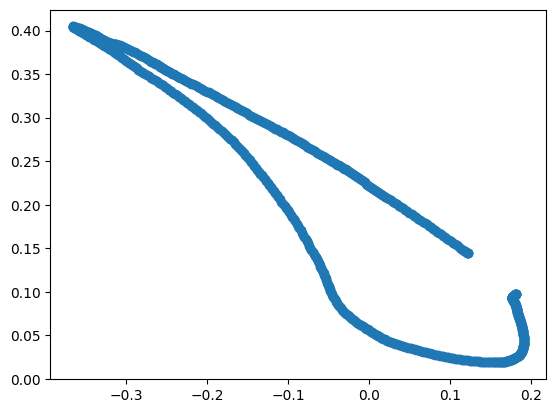

In [133]:
print(q_init.shape)
q_init_latent = nnx.vmap(lambda x : autoencoder.encoder(x), in_axes=1, out_axes=1)(q_init) # (2, n)

print(q_init_latent.shape)
plt.scatter(q_init_latent[0,:], q_init_latent[1,:])

(2, 770, 17)


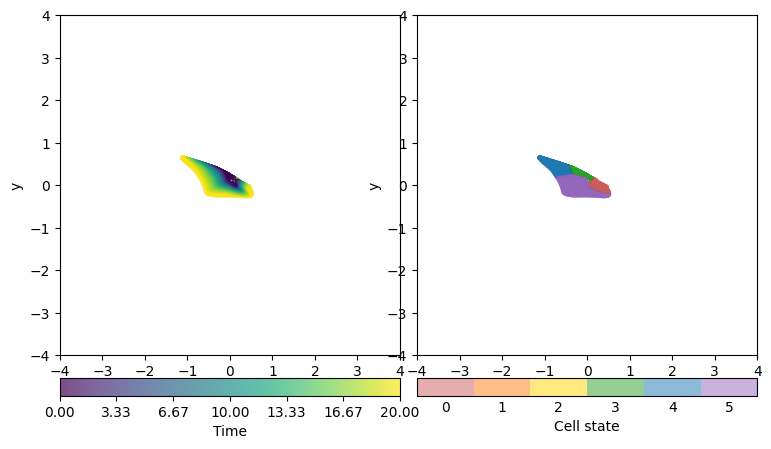

In [134]:
traj, states = autoencoder.landscape_flax(q_init_latent)

print(traj.shape)

fig = plot_traj(traj, states, t0, tf, nt, L=4)

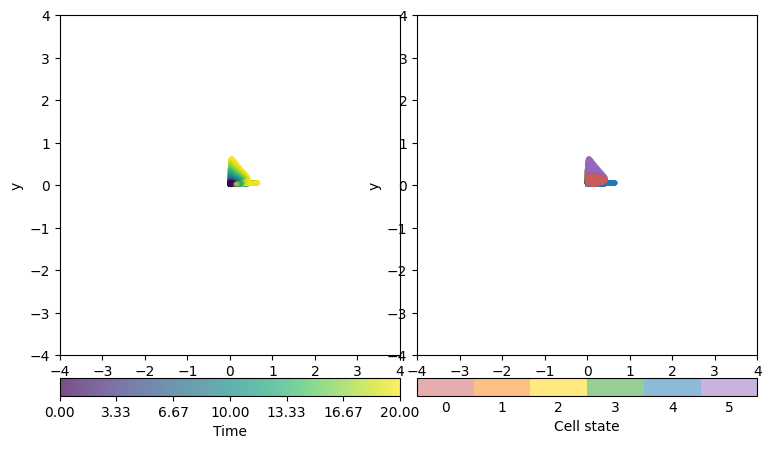

In [135]:
fig = plot_traj(target_traj, states, t0, tf, nt, L=4)

This (below) shows the trajectory of the cells. The color is the proportion of one real gene (for example Kr).

In [136]:
import numpy as np
import matplotlib.pyplot as plt


def plot_colored_trajectories(
    traj_2d,
    traj_4d,
    cmap="Blues",
    point_size=10,
    linewidth=0.5,
    alpha_line=0.3,
    figsize=(12, 12),
):
    """
    Affiche les trajectoires 2D colorées par chacune des 4 coordonnées
    du tableau décodé.

    Parameters
    ----------
    traj_2d : ndarray, shape (2, N, T)
    traj_4d : ndarray, shape (4, N, T)
    """

    gene_names = ["Gt", "Kni", "Hb", "Kr"]

    assert traj_2d.shape[0] == 2
    assert traj_4d.shape[0] == 4
    assert traj_2d.shape[1:] == traj_4d.shape[1:]

    n_particles, T = traj_2d.shape[1:]

    x = traj_2d[0]
    y = traj_2d[1]

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.ravel()

    for dim in range(4):

        values = traj_4d[dim]
        vmin = values.min()
        vmax = values.max()

        ax = axes[dim]

        for i in range(n_particles):

            # Trajectoire en gris
            ax.plot(
                x[i],
                y[i],
                color="lightgray",
                linewidth=linewidth,
                alpha=alpha_line,
                zorder=1,
            )

            # Points colorés
            sc = ax.scatter(
                x[i],
                y[i],
                c=values[i],
                cmap=cmap,
                s=point_size,
                vmin=vmin,
                vmax=vmax,
                zorder=2,
            )

        ax.set_xlim(-4, 4)
        ax.set_ylim(-4, 4)
        ax.set_aspect("equal")
        ax.set_title(gene_names[dim])
        ax.set_xlabel("x")
        ax.set_ylabel("y")

        plt.colorbar(sc, ax=ax)

    plt.tight_layout()
    plt.show()

(4, 770, 17)
(2, 770, 17)


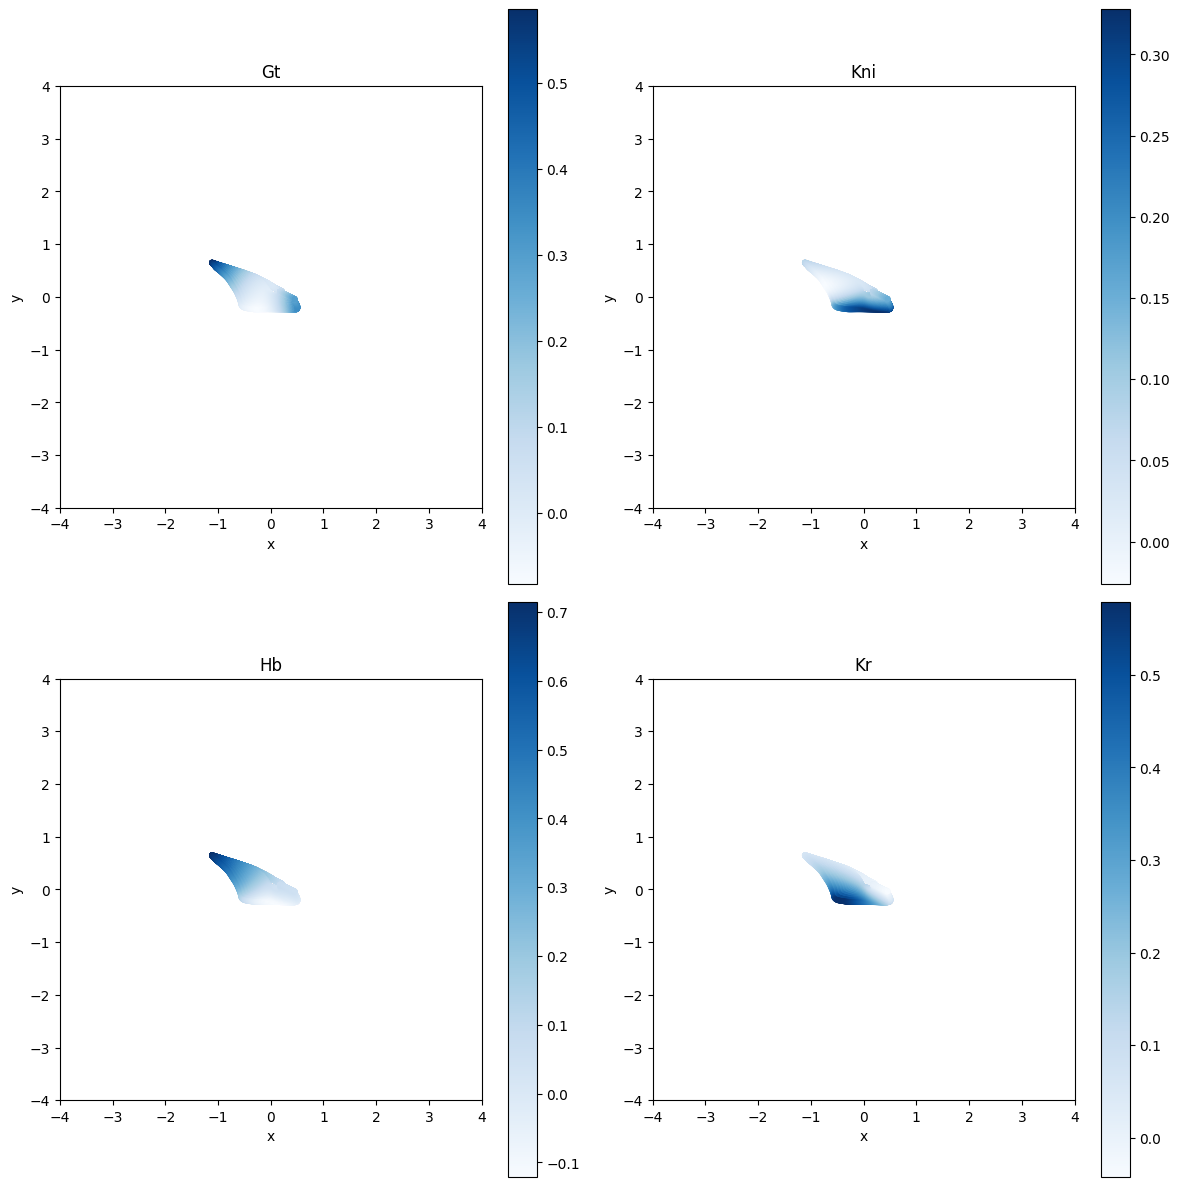

In [137]:
traj_4d = autoencoder(q_init)

q_init_latent = nnx.vmap(lambda x : autoencoder.encoder(x), in_axes=1, out_axes=1)(q_init) # (2, n)
traj_2d, states = autoencoder.landscape_flax(q_init_latent)

print(traj_4d.shape)
print(traj_2d.shape)

plot_colored_trajectories(traj_2d, traj_4d)

Below is the reproducing fig4 in "Latent space of a small genetic network: Geometry of dynamics and information", but with the landscape.
You can see the result in evolution.gif

In [138]:
import numpy as np
import matplotlib.pyplot as plt

def compare_trajectories(traj_sim, traj_real, gene_names=None, title=None):
    """
    Compare deux trajectoires de taille (4, T) sur un seul graphe.

    Parameters
    ----------
    traj_sim : ndarray, shape (4, T)
        Trajectoire simulée.
    traj_real : ndarray, shape (4, T)
        Trajectoire réelle.
    gene_names : list of str, optional
        Nom des 4 gènes.
    title : str, optional
        Titre de la figure.
    """
    traj_sim = np.asarray(traj_sim)
    traj_real = np.asarray(traj_real)

    if traj_sim.shape != traj_real.shape:
        raise ValueError("Les deux tableaux doivent avoir la même taille.")
    if traj_sim.shape[0] != 4:
        raise ValueError("Les tableaux doivent être de taille (4, T).")

    if gene_names is None:
        gene_names = [f"Gène {i+1}" for i in range(4)]

    T = traj_sim.shape[1]
    t = np.arange(T)

    fig, ax = plt.subplots(figsize=(10, 6))

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for i in range(4):
        color = colors[i % len(colors)]

        ax.plot(
            t, traj_sim[i],
            color=color,
            linewidth=2,
            linestyle="-",
            label=f"{gene_names[i]} (simulation)"
        )

        ax.plot(
            t, traj_real[i],
            color=color,
            linewidth=2,
            linestyle="--",
            label=f"{gene_names[i]} (réel)"
        )

    ax.set_xlabel("Timepoint")
    ax.set_ylabel("Concentration")
    ax.grid(True)
    ax.legend(ncol=2)

    if title is not None:
        ax.set_title(title)

    plt.tight_layout()
    plt.show()

(4, 770, 17)
(4, 770)
(4, 770)


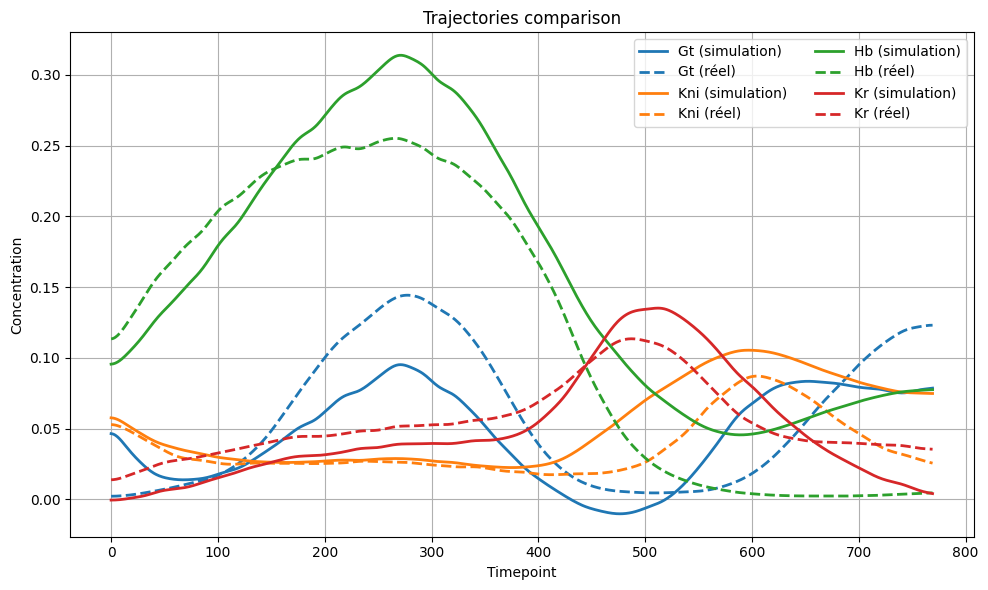

In [139]:
sim_traj_4d = autoencoder(q_init)
print(sim_traj_4d.shape)

time_idx = 0

real_traj = target_traj[:, :, time_idx]
sim_traj = sim_traj_4d[:, :, time_idx]

print(real_traj.shape)
print(sim_traj.shape)

compare_trajectories(
    sim_traj,
    real_traj,
    gene_names=["Gt", "Kni", "Hb", "Kr"],
    title="Trajectories comparison"
)

### Creating a gif

In [140]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

def make_gene_gif(
    sim,
    real=None,
    x=None,
    gene_names=None,
    fps=5,
    filename="gene_evolution.gif",
):
    """
    Génère un GIF montrant l'évolution temporelle des concentrations.

    Parameters
    ----------
    sim : ndarray (n_genes, n_space, n_time)
        Données simulées.
    real : ndarray (n_genes, n_space, n_time), optional
        Données réelles.
    x : ndarray (n_space,), optional
        Coordonnées spatiales.
    gene_names : list of str, optional
        Noms des gènes.
    fps : int
        Images par seconde.
    filename : str
        Nom du fichier gif.
    """

    sim = np.asarray(sim)

    if real is not None:
        real = np.asarray(real)
        if sim.shape != real.shape:
            raise ValueError("sim et real doivent avoir la même taille.")

    n_genes, n_space, n_time = sim.shape

    if x is None:
        x = np.arange(n_space)

    if gene_names is None:
        gene_names = [f"Gène {i+1}" for i in range(n_genes)]

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    fig, ax = plt.subplots(figsize=(8, 5))

    sim_lines = []
    real_lines = []

    # bornes fixes pour éviter que l'échelle change
    ymin = sim.min()
    ymax = sim.max()

    if real is not None:
        ymin = min(ymin, real.min())
        ymax = max(ymax, real.max())

    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(ymin, ymax)

    ax.set_xlabel("Coordonnée spatiale")
    ax.set_ylabel("Concentration")

    for g in range(n_genes):
        c = colors[g % len(colors)]

        line_sim, = ax.plot(
            x,
            sim[g, :, 0],
            color=c,
            lw=2,
            label=f"{gene_names[g]} (simulation)"
        )
        sim_lines.append(line_sim)

        if real is not None:
            line_real, = ax.plot(
                x,
                real[g, :, 0],
                "--",
                color=c,
                lw=2,
                label=f"{gene_names[g]} (réel)"
            )
            real_lines.append(line_real)

    title = ax.set_title("")

    ax.legend(ncol=2)

    def update(frame):

        for g in range(n_genes):
            sim_lines[g].set_ydata(sim[g, :, frame])

            if real is not None:
                real_lines[g].set_ydata(real[g, :, frame])

        title.set_text(f"Timepoint {frame}")

        artists = sim_lines.copy()
        if real is not None:
            artists += real_lines
        artists.append(title)

        return artists

    anim = FuncAnimation(
        fig,
        update,
        frames=n_time,
        interval=1000 // fps,
        blit=True,
    )

    anim.save(filename, writer=PillowWriter(fps=fps))
    plt.close(fig)

    print(f"GIF enregistré dans {filename}")

In [141]:
# sim.shape = (4, 100, 50)
# real.shape = (4, 100, 50)

x = np.linspace(0, 1, 770)

make_gene_gif(
    sim_traj_4d,
    target_traj,
    x=x,
    gene_names=["Gt", "Kni", "Hb", "Kr"],
    fps=4,
    filename="evolution.gif",
)

GIF enregistré dans evolution.gif
